In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

In [2]:
from dask.distributed import Client
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36251 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36251/status,
Dashboard: /proxy/36251/status,Workers: 7
Total threads: 7,Total memory: 256.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34687,Workers: 0
Dashboard: /proxy/36251/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40297,Total threads: 1
Dashboard: /proxy/35813/status,Memory: 36.57 GiB
Nanny: tcp://127.0.0.1:40367,


### Staggered grid (shared across all experiments)

In [3]:
Lx = 1000e3
Ly = 400e3
dx = 1000
dy = 1000
nx = int(Lx/dx)
ny = int(Ly/dy)
nxp = nx + 1
nyp = ny + 1

xh = np.linspace(dx/2, Lx - dx/2, nx)
yh = np.linspace(dy/2, Ly - dy/2, ny)
xq = np.linspace(0, Lx, nxp)
yq = np.linspace(0, Ly, nyp)

Xh, Yh   = np.meshgrid(xh, yh)
Xq, Yh_u = np.meshgrid(xq, yh)
Xh_v, Yq = np.meshgrid(xh, yq)

In [4]:
f = -1e-5
g = 9.81

### Velocity profile — computed once, shared across all experiments

All experiments (test70–test80) use the **same** tanh velocity profile and **same** noise realisation (fixed seed).

In [5]:
U    = 0.20
Ljet = 10e3
y0   = Ly / 2

yprime_h = (Yh   - y0) / Ljet
yprime_u = (Yh_u - y0) / Ljet
yprime_v = (Yq   - y0) / Ljet

u_clean = U * np.tanh(yprime_u)
v       = np.zeros((nyp, nx))

rng          = np.random.default_rng(seed=42)
random_noise = rng.standard_normal(u_clean.shape)
decay_factor = 1.0 / np.cosh(yprime_u)**2
noise        = 1e-3 * decay_factor * random_noise
u            = u_clean + noise

eta_t  = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
eta_t -= eta_t.mean()

zl   = 1
z    = np.array([-250.0])
h_3d = eta_t[np.newaxis, :, :]
u_3d = u    [np.newaxis, :, :]
v_3d = v    [np.newaxis, :, :]

print('Velocity and eta fields computed - shared by all experiments.')

Velocity and eta fields computed - shared by all experiments.


### Experiment loop — test70 to test80

Replicates test41–51 (varying slope width, fixed deep depth at 500 m) but adds a
**2-cell near-vertical drop to 1000 m** immediately after the gentle slope ends.

**Fixed across all experiments:**
- Velocity profile: tanh (same as all previous sets)
- Shallow shelf depth: 100 m
- Depth at base of gentle slope: 500 m
- Deep abyss depth: 1000 m (reached after 2-cell drop)
- Slope centre: cell 200 (even widths) or cell 201 (odd widths) 

**Varies between experiments — slope width:**



| Experiment | From  | Width | slope_start | slope_end | drop_end | Centre cell |
|------------|-------|-------|-------------|-----------|----------|-------------|
| test70     | test41| 5     | 199         | 204       | 206      | 201         |
| test71     | test42| 10    | 195         | 205       | 207      | 200         |
| test72     | test43| 15    | 194         | 209       | 211      | 201         |
| test73     | test44| 20    | 190         | 210       | 212      | 200         |
| test74     | test45| 25    | 189         | 214       | 216      | 201         |
| test75     | test46| 30    | 185         | 215       | 217      | 200         |
| test76     | test47| 35    | 184         | 219       | 221      | 201         |
| test77     | test48| 40    | 180         | 220       | 222      | 200         |
| test78     | test49| 45    | 179         | 224       | 226      | 201         |
| test79     | test50| 50    | 175         | 225       | 227      | 200         |
| test80     | test51| 55    | 174         | 229       | 231      | 201         |

In [6]:
base_dir      = '/scratch/nm03/ae7501/mom6_input_directories/idealized'
shallow_depth = 100.0   # m - flat shelf
deep_depth    = 500.0   # m - depth at base of gentle slope (same as test41-51)
abyss_depth   = 1000.0  # m - flat basin beyond the 2-cell drop

# Slope centring rule (no half-cells):
#   Even slope widths -> centred on cell 200
#   Odd  slope widths -> centred on cell 201
def slope_indices(slope_width):
    if slope_width % 2 == 0:
        start = 200 - slope_width // 2
    else:
        start = 201 - slope_width // 2
    return start, start + slope_width   # (inclusive, exclusive)

# Experiment list: (new_exp_number, slope_width) — mirrors test41-51
experiments = [(70 + i, (i + 1) * 5) for i in range(11)]

for exp_num, slope_width in experiments:

    exp_name  = f'test{exp_num}'
    input_dir = os.path.join(base_dir, exp_name, 'INPUT')

    slope_start, slope_end = slope_indices(slope_width)
    drop_start = slope_end        # 2-cell drop begins immediately after slope
    drop_end   = slope_end + 2
    centre_cell = slope_start + slope_width // 2

    os.makedirs(input_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f' {exp_name}  |  slope_width={slope_width}  centre={centre_cell}'
          f'  slope=[{slope_start},{slope_end})  drop=[{drop_start},{drop_end})')

    # Bathymetry:
    #   [0          : slope_start] flat at shallow_depth (100 m)
    #   [slope_start : slope_end ] linear drop: 100 m -> 500 m
    #   [drop_start  : drop_end  ] 2-cell near-vertical drop: 500 m -> 1000 m
    #   [drop_end   :            ] flat at abyss_depth (1000 m)
    depth_profile_y = np.zeros(ny)
    depth_profile_y[:slope_start]          = shallow_depth
    depth_profile_y[slope_start:slope_end] = np.linspace(shallow_depth, deep_depth, slope_width)
    depth_profile_y[drop_start:drop_end]   = np.linspace(deep_depth, abyss_depth, 3)[1:]
    depth_profile_y[drop_end:]             = abyss_depth

    depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))

    # --- init_vel.nc ---
    vel_path = os.path.join(input_dir, 'init_vel.nc')
    nc_vel = Dataset(vel_path, 'w', format='NETCDF4')
    nc_vel.createDimension('zl', zl)
    nc_vel.createDimension('yh', ny)
    nc_vel.createDimension('xh', nx)
    nc_vel.createDimension('yq', nyp)
    nc_vel.createDimension('xq', nxp)

    zl_v = nc_vel.createVariable('zl', 'f4', ('zl',))
    zl_v[:] = z ; zl_v.axis = 'Z' ; zl_v.long_name = 'depth to layer'

    xh_v = nc_vel.createVariable('xh', 'f4', ('xh',))
    xh_v[:] = xh ; xh_v.axis = 'X'
    xh_v.long_name = 'h-point longitude' ; xh_v.units = 'meters'

    yh_v = nc_vel.createVariable('yh', 'f4', ('yh',))
    yh_v[:] = yh ; yh_v.axis = 'Y'
    yh_v.long_name = 'h-point latitude' ; yh_v.units = 'meters'

    xq_v = nc_vel.createVariable('xq', 'f4', ('xq',))
    xq_v[:] = xq ; xq_v.axis = 'X'
    xq_v.long_name = 'q-point longitude' ; xq_v.units = 'meters'

    yq_v = nc_vel.createVariable('yq', 'f4', ('yq',))
    yq_v[:] = yq ; yq_v.axis = 'Y'
    yq_v.long_name = 'q-point latitude' ; yq_v.units = 'meters'

    u_var = nc_vel.createVariable('u', 'f4', ('zl', 'yh', 'xq'))
    u_var[:] = u_3d
    u_var.units = 'm s-1'
    u_var.long_name = 'Eastward velocity'
    u_var.standard_name = 'eastward_sea_water_velocity'

    v_var = nc_vel.createVariable('v', 'f4', ('zl', 'yq', 'xh'))
    v_var[:] = v_3d
    v_var.units = 'm s-1'
    v_var.long_name = 'Northward velocity'
    v_var.standard_name = 'northward_sea_water_velocity'

    nc_vel.regrid_method = 'bilinear'
    nc_vel.close()
    print(f' Written: {vel_path}')

    # --- init_eta.nc ---
    eta_path = os.path.join(input_dir, 'init_eta.nc')
    nc_h = Dataset(eta_path, 'w', format='NETCDF4')
    nc_h.createDimension('yh', ny)
    nc_h.createDimension('xh', nx)

    xh_v2 = nc_h.createVariable('xh', 'f4', ('xh',))
    xh_v2[:] = xh ; xh_v2.axis = 'X'
    xh_v2.long_name = 'h-point longitude' ; xh_v2.units = 'meters'

    yh_v2 = nc_h.createVariable('yh', 'f4', ('yh',))
    yh_v2[:] = yh ; yh_v2.axis = 'Y'
    yh_v2.long_name = 'h-point latitude' ; yh_v2.units = 'meters'

    h_var = nc_h.createVariable('eta_t', 'f4', ('yh', 'xh'))
    h_var[:] = h_3d
    h_var.units = 'm'
    h_var.long_name = 'Free surface height anomaly'
    h_var.standard_name = 'sea_floor_depth_below_sea_surface'

    nc_h.close()
    print(f' Written: {eta_path}')

    # --- ocean_topog.nc ---
    topo_path = os.path.join(input_dir, 'ocean_topog.nc')
    nc_d = Dataset(topo_path, 'w', format='NETCDF4')
    nc_d.createDimension('yh', ny)
    nc_d.createDimension('xh', nx)

    xh_d = nc_d.createVariable('xh', 'f4', ('xh',))
    xh_d[:] = xh
    xh_d.long_name = 't-cell center x-location' ; xh_d.units = 'meters'

    yh_d = nc_d.createVariable('yh', 'f4', ('yh',))
    yh_d[:] = yh
    yh_d.long_name = 't-cell center y-location' ; yh_d.units = 'meters'

    depth_var = nc_d.createVariable('depth', 'f4', ('yh', 'xh'))
    depth_var[:] = depth_2d
    depth_var.units = 'm'
    depth_var.long_name = 'ocean bottom depth'
    depth_var.standard_name = 'sea_floor_depth_below_geoid'

    nc_d.close()
    print(f' Written: {topo_path}')

print(f"\n{'='*60}")
print('All 11 experiments written successfully (test70-test80).')
print(f"{'='*60}")


 test70  |  slope_width=5  centre=201  slope=[199,204)  drop=[204,206)
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test70/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test70/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test70/INPUT/ocean_topog.nc

 test71  |  slope_width=10  centre=200  slope=[195,205)  drop=[205,207)
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test71/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test71/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test71/INPUT/ocean_topog.nc

 test72  |  slope_width=15  centre=201  slope=[194,209)  drop=[209,211)
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test72/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test72/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/

### Sanity-check plot — bathymetry profiles for all experiments

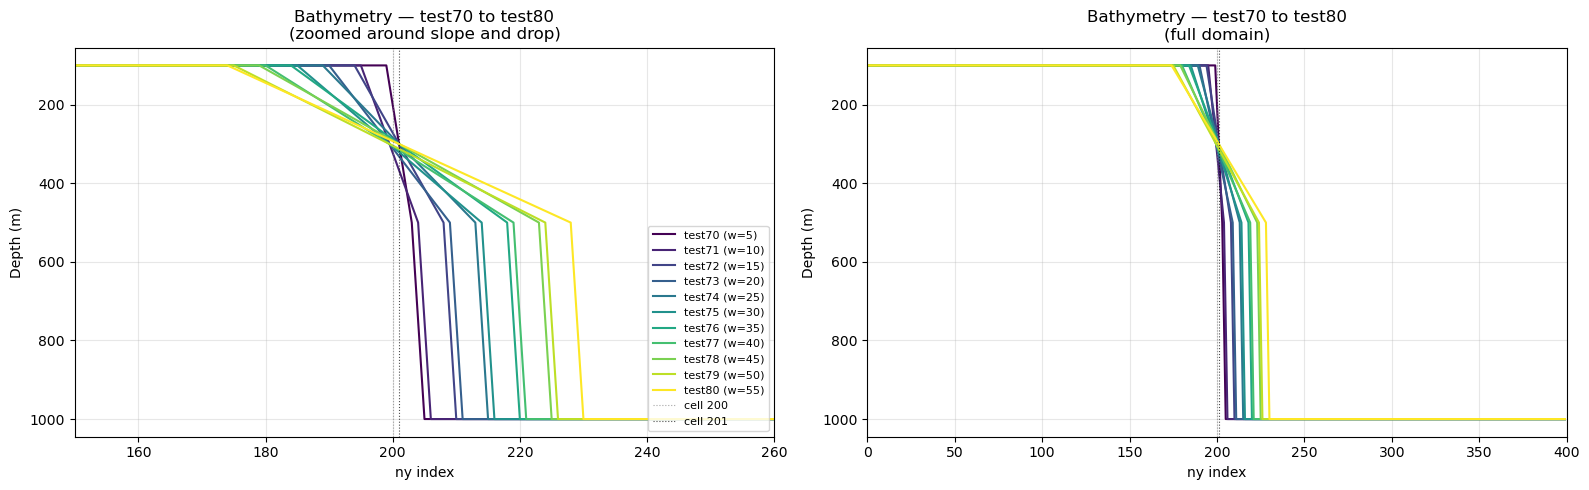

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(experiments)))

for ax, xlim, title_suffix in zip(
        axes,
        [(150, 260), (0, 400)],
        ['(zoomed around slope and drop)', '(full domain)']):

    for i, (exp_num, slope_width) in enumerate(experiments):
        slope_start, slope_end = slope_indices(slope_width)
        drop_start = slope_end
        drop_end   = slope_end + 2

        profile = np.zeros(ny)
        profile[:slope_start]          = shallow_depth
        profile[slope_start:slope_end] = np.linspace(shallow_depth, deep_depth, slope_width)
        profile[drop_start:drop_end]   = np.linspace(deep_depth, abyss_depth, 3)[1:]
        profile[drop_end:]             = abyss_depth

        ax.plot(np.arange(ny), profile, color=colors[i],
                label=f'test{exp_num} (w={slope_width})')

    ax.axvline(200, color='gray', linestyle=':', linewidth=0.8, alpha=0.7, label='cell 200')
    ax.axvline(201, color='k',    linestyle=':', linewidth=0.8, alpha=0.7, label='cell 201')
    ax.set_xlim(xlim)
    ax.set_xlabel('ny index')
    ax.set_ylabel('Depth (m)')
    ax.invert_yaxis()
    ax.set_title(f'Bathymetry — test70 to test80\n{title_suffix}')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()